## Import thư viện và các thiết lập cần thiết

In [1]:
#@title Supress scikit-learn warning
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import skew
from scipy.stats.stats import pearsonr
from sklearn.metrics import mean_squared_log_error, make_scorer

# Tiền xử lý
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

# Thư viện scikit-learn cho học máy
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

# Các mô hình máy học tuyến tính
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, LassoCV, LassoLarsCV, Lasso

# Mô hình phi tuyến
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor, VotingRegressor

from sklearn.model_selection import GridSearchCV

# Mô hình xgb
import xgboost as xgb

%config InlineBackend.figure_format = 'retina' #set 'png' here when working on notebook
%matplotlib inline
np.random.seed(1)
     

## 1.Khám phá dữ liệu

### 1.1 Các tập train

In [3]:
data_df = pd.read_csv('train.csv', index_col=0)
data_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Số dòng X cột của dữ liệu train
data_df.shape

(1460, 80)

In [5]:
test_X = pd.read_csv('test.csv', index_col=0)
test_y = pd.read_csv('test_result.csv', index_col=0)['SalePrice']
test_X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
# Số dòng X cột của dữ liệu test
test_X.shape

(1459, 79)

### 1.2 Khám phá các cột (thuộc tính) của dữ liệu

In [7]:
with open('data_description.txt', 'r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [8]:
data_df.dtypes.unique().tolist()

[dtype('int64'),
 <StringDtype(storage='python', na_value=nan)>,
 dtype('float64')]

In [9]:
cat_cols = data_df.dtypes.index[ data_df.dtypes == 'O' ].tolist()
num_cols = data_df.dtypes.index[ data_df.dtypes != 'O' ].tolist()
num_cols.remove('SalePrice')

In [10]:
data_df[num_cols].describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [11]:
cat_cols = data_df.select_dtypes(include=['object', 'category']).columns

In [12]:
data_df[cat_cols].describe()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


### 1.3 Khám phá cột giá nhà

In [13]:
data_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

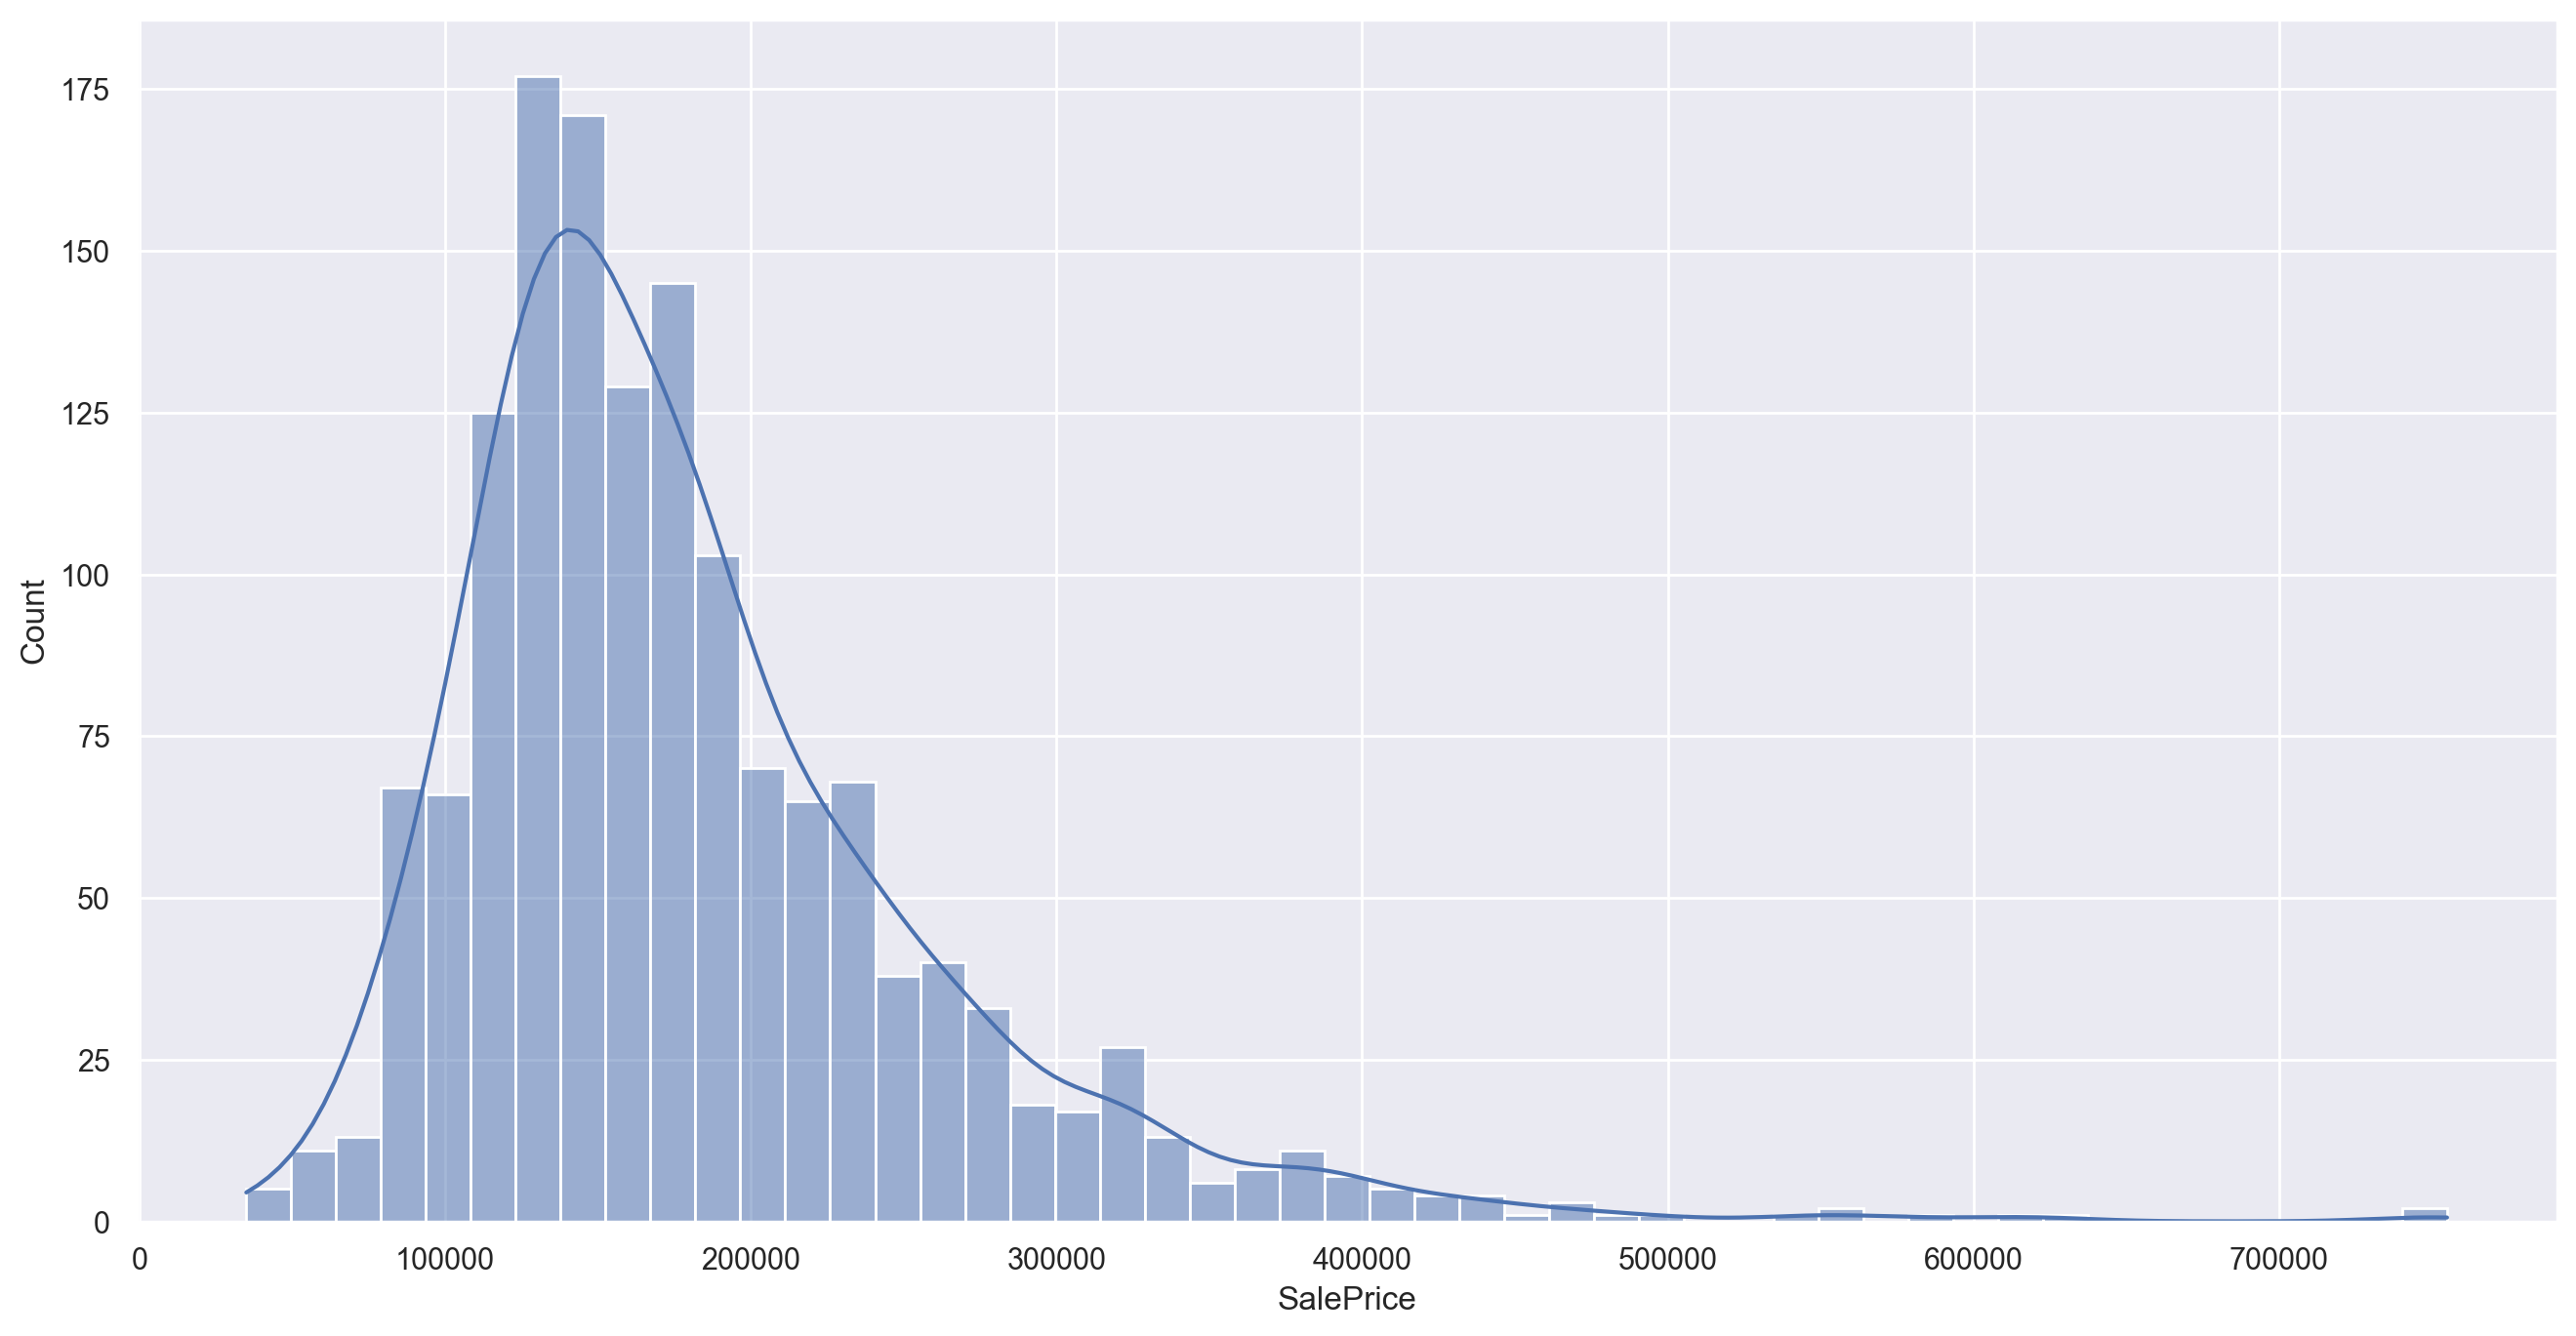

In [14]:
sns.set(rc={'figure.figsize':(16,8)})
sns.histplot(data_df['SalePrice'],kde=True)

In [15]:
print("Skewness: ",round(data_df['SalePrice'].skew(),4))
print("Kurtosis: ",round(data_df['SalePrice'].kurt(),4))

Skewness:  1.8829
Kurtosis:  6.5363


### 1.4 Khám phá dữ liệu thiếu

In [16]:
missing = data_df.isnull().sum()
missing = missing[missing > 0]
missing_stats = pd.DataFrame({
  'Column Name': missing.index,
  'Count': missing.to_list(),
  'Ratio': np.round(missing/data_df.shape[0]*100,2).to_list()  
})

In [17]:
cm = sns.light_palette("red", as_cmap=True)
missing_stats.style.background_gradient(cmap=cm)

,Column Name,Count,Ratio
0,LotFrontage,259,17.740000
1,Alley,1369,93.770000
2,MasVnrType,872,59.730000
3,MasVnrArea,8,0.550000
4,BsmtQual,37,2.530000
5,BsmtCond,37,2.530000
6,BsmtExposure,38,2.600000
7,BsmtFinType1,37,2.530000
8,BsmtFinType2,38,2.600000
9,Electrical,1,0.070000


Text(0.5, 0, 'Missing Count')

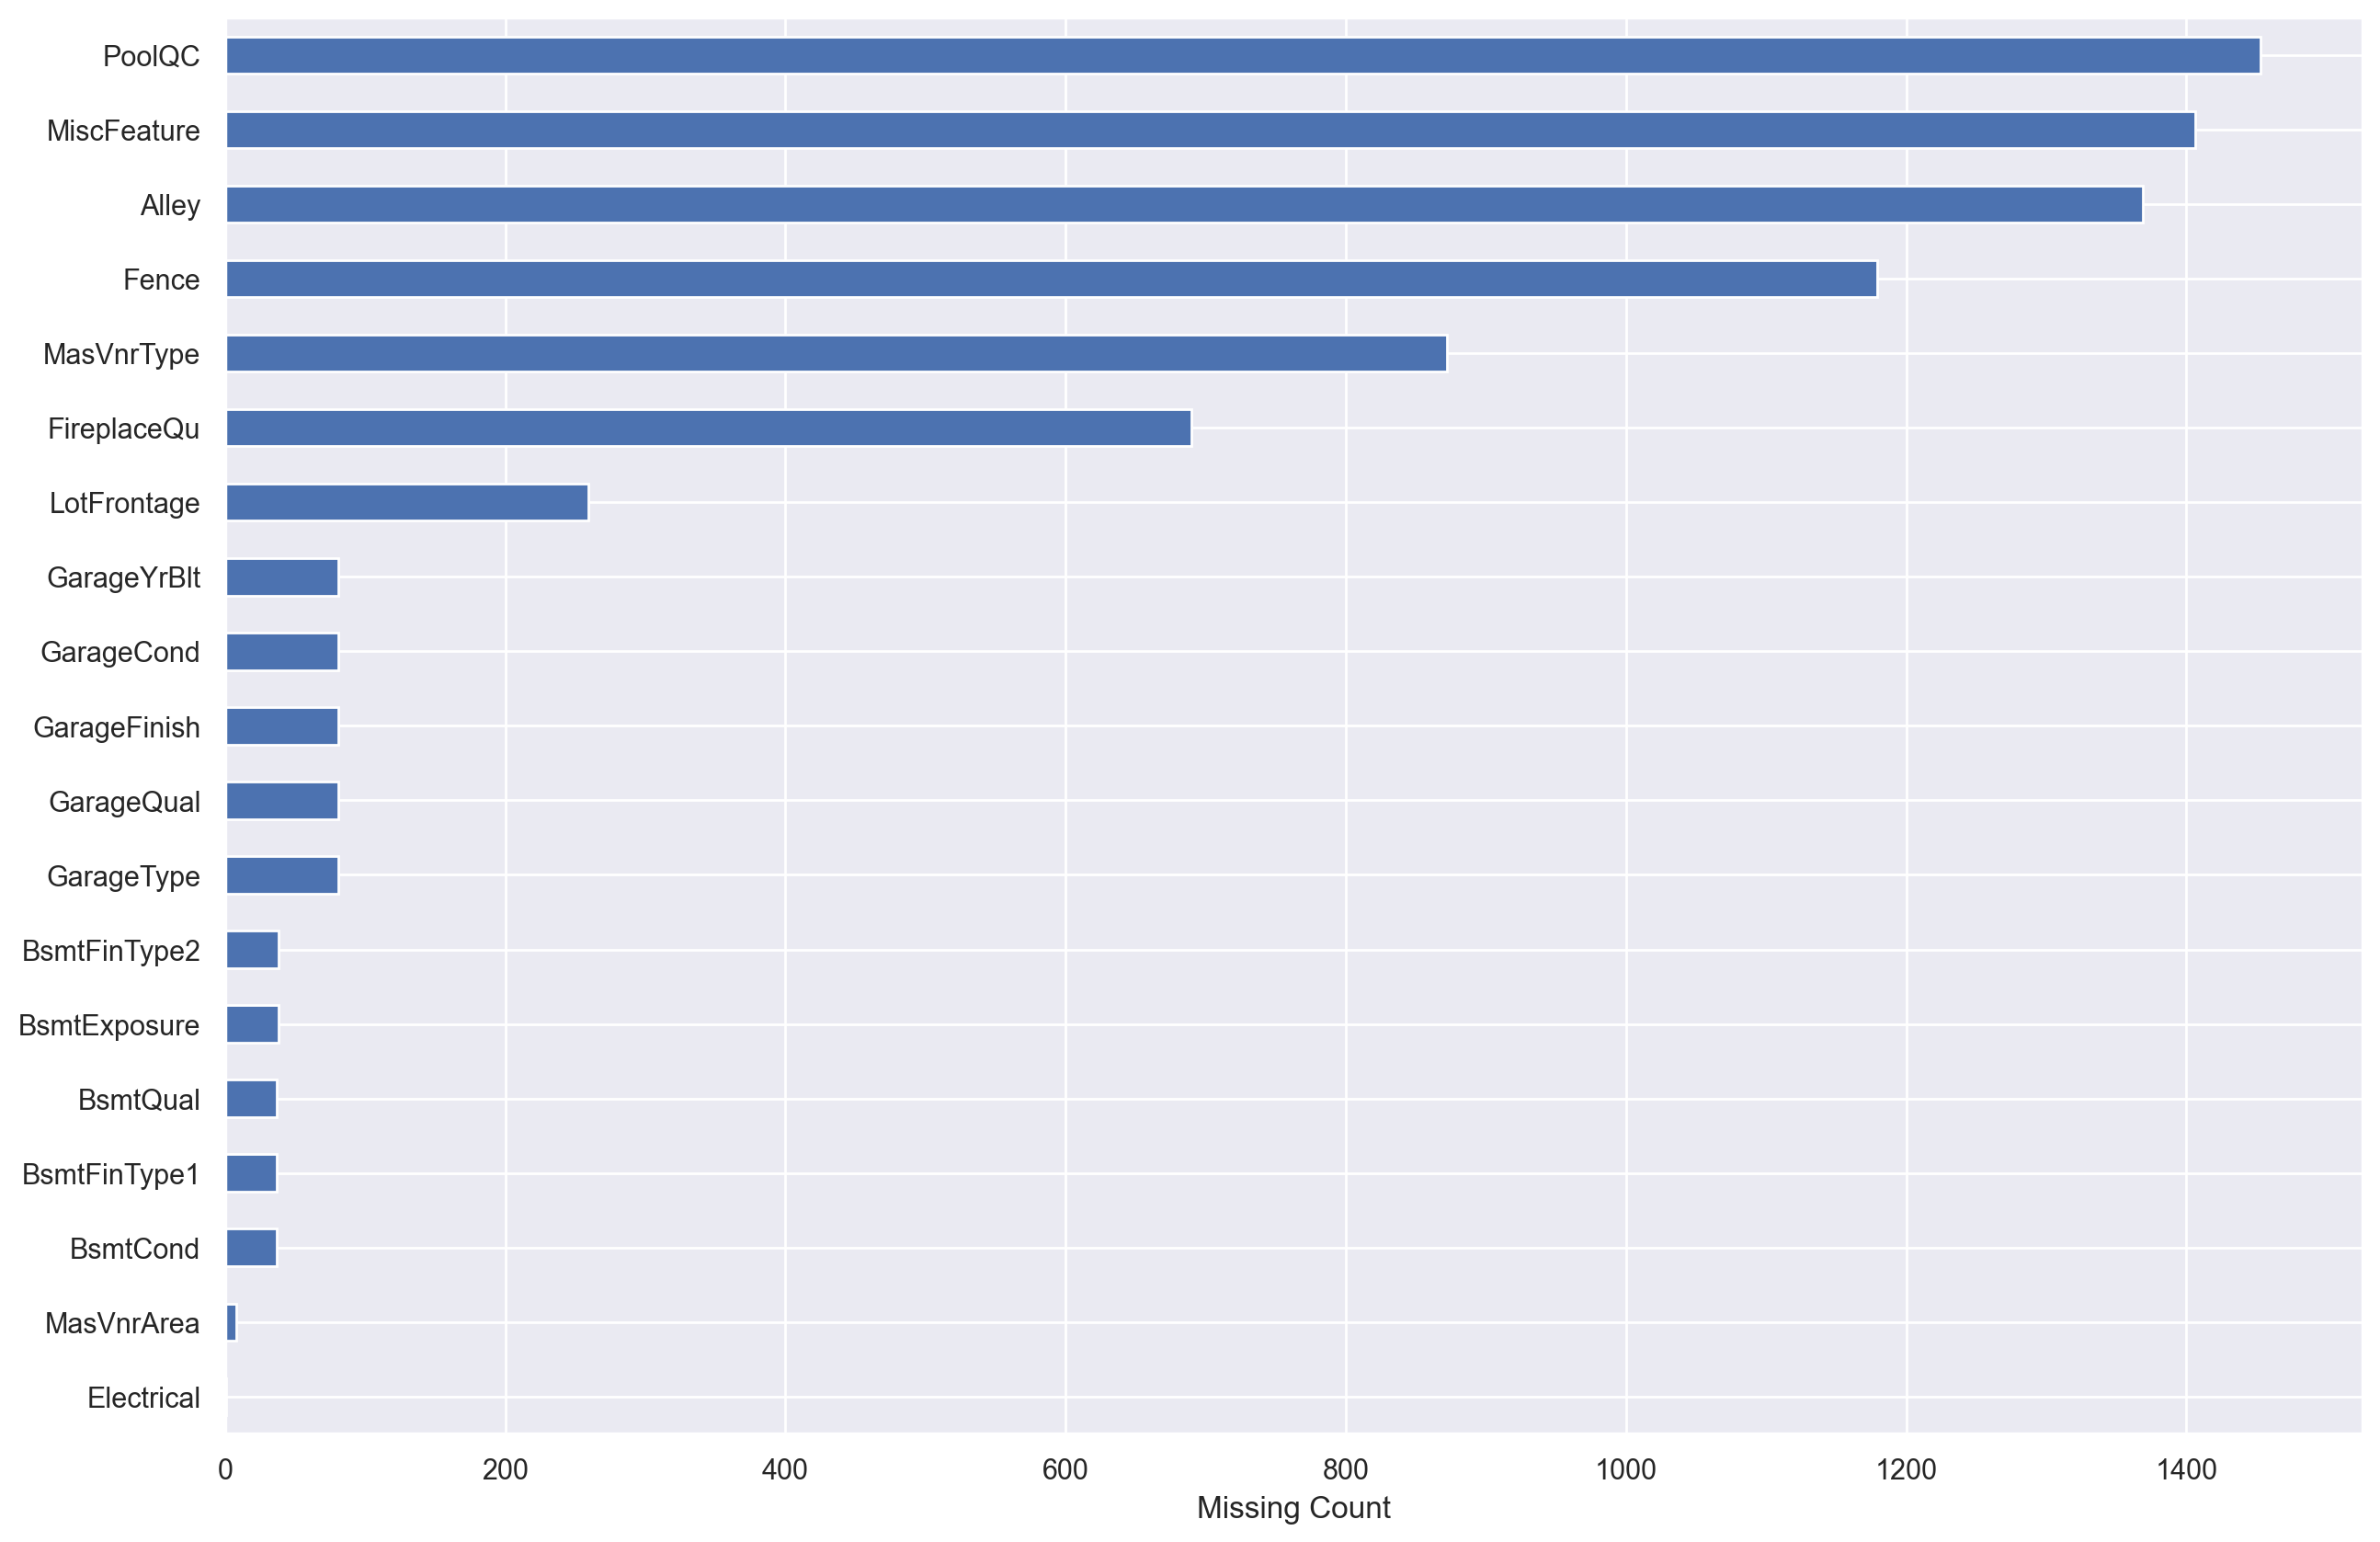

In [18]:
ax = missing.sort_values().plot.barh(figsize=(15,10))
ax.set_xlabel('Missing Count')

## 2.Preprocess(Tiền xử lý dữ liệu)

### 2.1 Log và Exp transformation

In [19]:
test_y = np.log1p(test_y)
data_df["SalePrice"] = np.log1p(data_df["SalePrice"])
data_df["SalePrice"]

Id
1       12.247699
2       12.109016
3       12.317171
4       11.849405
5       12.429220
          ...    
1456    12.072547
1457    12.254868
1458    12.493133
1459    11.864469
1460    11.901590
Name: SalePrice, Length: 1460, dtype: float64

In [20]:
# 1. Lấy đúng cột numeric
numeric_feats = data_df.select_dtypes(include=[np.number]).columns

# 2. Ép kiểu (tránh lỗi string lẫn vào)
data_df[numeric_feats] = data_df[numeric_feats].apply(pd.to_numeric, errors='coerce')

# 3. Tính skew
skewed_feats = data_df[numeric_feats].apply(lambda x: skew(x.dropna()))

# 4. Chỉ lấy skew dương (QUAN TRỌNG)
skewed_feats = skewed_feats[skewed_feats > 0.75].index

# 5. Log transform
data_df[skewed_feats] = np.log1p(data_df[skewed_feats])

# 6. Áp dụng cho test (chỉ cột tồn tại)
common_cols = [col for col in skewed_feats if col in test_X.columns]
test_X[common_cols] = np.log1p(test_X[common_cols])

### 2.2 Tách tập


In [21]:
data_X = data_df.drop('SalePrice', axis=1)
data_y = data_df['SalePrice']

In [22]:
train_X, val_X, train_y, val_y = train_test_split(data_X, data_y,test_size=0.3)
train_X.shape, val_X.shape

((1022, 79), (438, 79))

### 2.3 Xây dựng pipeline

In [23]:
cat_cols = list(cat_cols)

mul_cols = ['Condition1', 'Condition2', 'Exterior1st', 'Exterior2nd', 'BsmtFinType1', 'BsmtFinType2']

cat_cols = [col for col in cat_cols if col not in mul_cols]

In [24]:
class OneHotEncoderM(TransformerMixin):
    def __init__(self, *args, **kwargs):
      self.dummy_value = 'MissingValue'
      self.imputer = SimpleImputer(strategy='constant', fill_value=self.dummy_value)
      self.encoder = OneHotEncoder(*args, **kwargs)

    def fit(self, x, y=0):
      self.encoder.fit(self.imputer.fit_transform(x))
      # Remove dummy value from dict
      self.encoder.categories_ = [arr[arr != self.dummy_value] for arr in self.encoder.categories_]
      return self
      
    def transform(self, x, y=0):
      return self.encoder.transform(x)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='MissingValue')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [25]:
class MultiHotEncoder(TransformerMixin):
    def __init__(self, *args, **kwargs):
      self.dummy_value = 'zzMissingzz'
      self.encoder = MultiLabelBinarizer(*args, **kwargs)

    def fit(self, x, y=0):
      self.encoder.fit(x.fillna(self.dummy_value).values)
      # Remove dummy value from dict
      self.encoder.classes_ = self.encoder.classes_[self.encoder.classes_ != self.dummy_value]
      # Remove cached value
      self.encoder._cached_dict = None
      return self
      
    def transform(self, x, y=0):
      return self.encoder.transform(x.values)

multilabel_transformer =  Pipeline(steps=[
    ('multilabel',MultiHotEncoder())
])

In [26]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, num_cols),
        ('multi_label', multilabel_transformer, mul_cols),
        ('categorical', categorical_transformer, cat_cols)
        ])

preprocess_pipeline=Pipeline(steps=[('preprocessor', preprocessor)])

## 3.Mô hình hóa


### 3.1 Thử nghiệm các mô hình

#### Hàm thống kê độ lỗi

In [28]:
#@title Hàm RSMLE
def root_MSLE(y_true, y_pred):
  _y_pred = y_pred
  _y_pred[_y_pred < 0] = 0
  return mean_squared_log_error(y_true, _y_pred)**(1/2)

In [29]:
#@title Hàm thống kê độ lỗi
def error_stats(y, y_pred):
  df = pd.DataFrame({'Actual': np.expm1(y), 'Predicted':np.expm1(y_pred)})
  df['Absolute Error']=df['Actual']-df['Predicted']
  df['Relative Error']=(abs(df['Absolute Error'])/df['Actual'])*100
  MAPE = np.round(df['Relative Error'].mean(), 4)
  RMSLE = root_MSLE(np.expm1(y), np.expm1(y_pred))
  return (df, MAPE, RMSLE)

In [30]:
#@title Hàm TestModel
def TestModel(model):
  test_pred = model.predict(test_X)
  res_df, MAPE, RMSLE = error_stats(test_y, test_pred)
  print(f'RMSLE: {RMSLE}\n\
  MAPE: {MAPE}')

def TestModel_noprep(model, prep_pipe):
  p_test_X = prep_pipe.transform(test_X)
  test_pred = model.predict(p_test_X)
  res_df, MAPE, RMSLE = error_stats(test_y, test_pred)
  print(f'RMSLE: {RMSLE}\n\
  MAPE: {MAPE}')

#### 3.1.1 Gradient Boosting

In [31]:
loss = ['squared_error', 'absolute_error', 'huber', 'quantile']
alpha=[0.4,0.5,0.7,0.8,0.9,0.95,0.99]
gbr_hyperparam_tuning=pd.DataFrame(columns=['MAPE','RMSLE'])

In [32]:
# 1. Tách cột
numeric_features = train_X.select_dtypes(include=[np.number]).columns
categorical_features = train_X.select_dtypes(include=['object']).columns

# 2. Pipeline cho numeric
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# 3. Pipeline cho categorical
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Gộp lại
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [33]:
#@markdown Thử parameter
#%%capture
min=float('inf')
for iter_loss in loss:
  for iter_alpha in alpha:
    gbr = make_pipeline(preprocess_pipeline,
                        GradientBoostingRegressor(loss=iter_loss, alpha=iter_alpha, 
                                max_depth=4, n_estimators=100,random_state=22))
    gbr.fit(train_X, train_y)
    val_pred = gbr.predict(val_X)
    err_df_temp, mrE, RMSE = error_stats(val_y, val_pred)
    if RMSE<min:
      min=RMSE
      err_df=err_df_temp
      best_gbr=gbr
    gbr_hyperparam_tuning = pd.concat([
    gbr_hyperparam_tuning,
    pd.DataFrame([{
        'loss': iter_loss,
        'alpha': iter_alpha,
        'MAPE': mrE,
        'RMSLE': RMSE
    }])
], ignore_index=True)

In [34]:
gbr_hyperparam_tuning

,MAPE,RMSLE,loss,alpha
0,9.6454,0.140354,squared_error,0.40
1,9.6454,0.140354,squared_error,0.50
2,9.6454,0.140354,squared_error,0.70
3,9.6454,0.140354,squared_error,0.80
4,9.6454,0.140354,squared_error,0.90
5,9.6454,0.140354,squared_error,0.95
6,9.6454,0.140354,squared_error,0.99
7,10.892,0.158683,absolute_error,0.40
8,10.892,0.158683,absolute_error,0.50
9,10.892,0.158683,absolute_error,0.70


In [35]:
print("Mô hình cho RMSE nhỏ nhất với alpha=0.8 và loss='huber'.\nĐối với tập valuation:")
print(f"Độ sai tương đối trung bình: {gbr_hyperparam_tuning['MAPE'].iloc[10]} %")
print(f"RMSE: {gbr_hyperparam_tuning['RMSLE'].iloc[10]}")
err_df.head()

Mô hình cho RMSE nhỏ nhất với alpha=0.8 và loss='huber'.
Đối với tập valuation:
Độ sai tương đối trung bình: 10.892 %
RMSE: 0.1586826215341454


,Actual,Predicted,Absolute Error,Relative Error
Id,,,,
259,231500.0,205031.508845,26468.491155,11.433474
268,179500.0,165342.706248,14157.293752,7.887072
289,122000.0,121347.493662,652.506338,0.534841
650,84500.0,79079.853455,5420.146545,6.414375
1234,142000.0,142062.440134,-62.440134,0.043972


In [36]:
best_gbr.fit(data_X, data_y)
TestModel(best_gbr)

RMSLE: 0.13460438750421513
  MAPE: 8.8889


In [37]:
df=pd.DataFrame({'SalePrice':np.expm1(best_gbr.predict(test_X))})
df.index+=1461
df.reset_index(inplace=True)
df.rename({'index':'Id'},inplace=True,axis=1)
df.to_csv('gbr_final.csv',index=False)

#### 3.1.2 Ridge

In [38]:
alphas = [0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 50, 75]
solver = ["auto", "svd", "cholesky", "lsqr", "sparse_cg", "sag", "saga"]
ridge_hyperparam_tuning=pd.DataFrame(columns=['MAPE','RMSLE'])

In [39]:
#@markdown Thử parameter
#%%capture
min = float('inf')

for solv in solver:
    for iter_alpha in alphas:
        
        ridge = make_pipeline(
            preprocess_pipeline,
            Ridge(alpha=iter_alpha, tol=0.1, solver=solv)
        )

        ridge.fit(train_X, train_y)
        val_pred = ridge.predict(val_X)

        err_df_temp, mrE, RMSE = error_stats(val_y, val_pred)

        if RMSE < min:
            best_solver = solv
            best_alpha = iter_alpha
            min = RMSE
            err_df = err_df_temp
            best_ridge = ridge

        ridge_hyperparam_tuning = pd.concat([
            ridge_hyperparam_tuning,
            pd.DataFrame([{
                'solver': solv,
                'alpha': iter_alpha,
                'MAPE': mrE,
                'RMSLE': RMSE
            }])
        ], ignore_index=True)

In [40]:
ridge_hyperparam_tuning.iloc[0:20]

,MAPE,RMSLE,solver,alpha
0,9.6132,0.131644,auto,0.05
1,9.6087,0.131195,auto,0.10
2,9.6154,0.130862,auto,0.30
3,9.7054,0.132314,auto,1.00
4,9.796,0.13551,auto,3.00
5,9.8331,0.137052,auto,5.00
6,9.8842,0.138765,auto,10.00
7,9.9405,0.13967,auto,15.00
8,10.0879,0.141606,auto,30.00
9,10.26,0.143734,auto,50.00


In [41]:
print("Mô hình cho RMSE nhỏ nhất với alpha = ",best_alpha," và solver = ",best_solver,".\nĐối với tập valuation:")
print(f"Độ sai tương đối trung bình: {ridge_hyperparam_tuning['MAPE'].iloc[11]} %")
print(f"RMSE: {ridge_hyperparam_tuning['RMSLE'].iloc[11]}")
err_df.head()

Mô hình cho RMSE nhỏ nhất với alpha =  0.3  và solver =  auto .
Đối với tập valuation:
Độ sai tương đối trung bình: 9.6132 %
RMSE: 0.13164410788055467


,Actual,Predicted,Absolute Error,Relative Error
Id,,,,
259,231500.0,216755.753074,14744.246926,6.369005
268,179500.0,181590.456355,-2090.456355,1.164600
289,122000.0,112734.400937,9265.599063,7.594753
650,84500.0,82396.068512,2103.931488,2.489860
1234,142000.0,129691.393553,12308.606447,8.668033


In [42]:
best_ridge.fit(data_X, data_y)
TestModel(best_ridge)

RMSLE: 0.13431268330045132
  MAPE: 8.7993


In [43]:
df=pd.DataFrame({'SalePrice':np.expm1(best_ridge.predict(test_X))})
df.index+=1461
df.reset_index(inplace=True)
df.rename({'index':'Id'},inplace=True,axis=1)
df.to_csv('ridge_final.csv',index=False)

#### 3.1.3 Lasso

In [44]:
#Lasso
alphas = [0.05,0.02,0.01,0.005,0.002,0.001,0.0005,0.0002,0.0001]
lasso_hyperparam_tuning=pd.DataFrame(columns=['MAPE','RMSLE'])

In [45]:
#@markdown Thử parameter
#%%capture
min = float('inf')

for iter_alpha in alphas:
    
    lasso = make_pipeline(
        preprocess_pipeline,
        Lasso(alpha=iter_alpha, random_state=22, max_iter=10000, tol=0.01)
    )

    lasso.fit(train_X, train_y)

    if iter_alpha == 0:
        linear_regression = lasso

    val_pred = lasso.predict(val_X)
    err_df_temp, mrE, RMSE = error_stats(val_y, val_pred)

    if RMSE < min:
        min = RMSE
        err_df = err_df_temp
        best_lasso = lasso

    lasso_hyperparam_tuning = pd.concat([
        lasso_hyperparam_tuning,
        pd.DataFrame([{
            'alpha': iter_alpha,
            'MAPE': mrE,
            'RMSLE': RMSE
        }])
    ], ignore_index=True)

In [46]:
lasso_hyperparam_tuning

,MAPE,RMSLE,alpha
0,14.5673,0.194905,0.0500
1,12.6348,0.173763,0.0200
2,11.9412,0.165825,0.0100
3,10.748,0.150643,0.0050
4,9.904,0.140598,0.0020
5,9.6258,0.13774,0.0010
6,9.2404,0.131434,0.0005
7,9.1189,0.126424,0.0002
8,9.1927,0.126099,0.0001


In [47]:
print("Mô hình cho RMSE nhỏ nhất với alpha=0.0001.\nĐối với tập valuation:")
print(f"Độ sai tương đối trung bình: {lasso_hyperparam_tuning['MAPE'].iloc[8]} %")
print(f"RMSE: {lasso_hyperparam_tuning['RMSLE'].iloc[8]}")
err_df.head()

Mô hình cho RMSE nhỏ nhất với alpha=0.0001.
Đối với tập valuation:
Độ sai tương đối trung bình: 9.1927 %
RMSE: 0.12609940482237997


,Actual,Predicted,Absolute Error,Relative Error
Id,,,,
259,231500.0,214931.986412,16568.013588,7.156809
268,179500.0,186633.103782,-7133.103782,3.973874
289,122000.0,111723.932623,10276.067377,8.423006
650,84500.0,82613.330679,1886.669321,2.232745
1234,142000.0,127579.044055,14420.955945,10.155603


In [48]:
best_lasso.fit(data_X, data_y)
TestModel(best_lasso)

RMSLE: 0.1299755940966168
  MAPE: 8.4551


In [49]:
df=pd.DataFrame({'SalePrice':np.expm1(best_lasso.predict(test_X))})
df.index+=1461
df.reset_index(inplace=True)
df.rename({'index':'Id'},inplace=True,axis=1)
df.to_csv('lasso_final.csv',index=False)

#### 3.1.4 XGB

In [50]:
#XGB
lns = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]
xgb_hyperparam_tuning=pd.DataFrame(columns=['MAPE','RMSLE'])

In [51]:
p_train_X = preprocess_pipeline.fit_transform(train_X)
p_val_X = preprocess_pipeline.transform(val_X)
p_test_X = preprocess_pipeline.transform(test_X)

In [52]:
min = float('inf')

for iter_ln in lns:
    
    my_model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=iter_ln,
        random_state=22,
        objective='reg:squarederror',
        max_depth=2,
        eval_metric='rmse'
    )

    my_model.fit(
        p_train_X, train_y,
        early_stopping_rounds=100,
        eval_set=[(p_val_X, val_y)],
        verbose=False
    )

    val_pred = my_model.predict(p_val_X)

    err_df_temp, mrE, RMSE = error_stats(val_y, val_pred)

    if RMSE < min:
        min = RMSE
        err_df = err_df_temp
        best_xgb = my_model

    xgb_hyperparam_tuning = pd.concat([
        xgb_hyperparam_tuning,
        pd.DataFrame([{
            'learning_rates': iter_ln,
            'MAPE': mrE,
            'RMSLE': RMSE
        }])
    ], ignore_index=True)

In [53]:
xgb_hyperparam_tuning

,MAPE,RMSLE,learning_rates
0,10.705,0.148373,0.500
1,9.2472,0.131766,0.200
2,9.182,0.134374,0.100
3,9.2281,0.135122,0.050
4,9.711,0.139208,0.020
5,10.4044,0.149321,0.010
6,13.3139,0.182543,0.005


In [54]:
print("Mô hình cho RMSE nhỏ nhất với learning_rate = 0.2.\nĐối với tập valuation:")
print(f"Độ sai tương đối trung bình: {xgb_hyperparam_tuning['MAPE'].iloc[1]} %")
print(f"RMSE: {xgb_hyperparam_tuning['RMSLE'].iloc[1]}")
err_df.head()

Mô hình cho RMSE nhỏ nhất với learning_rate = 0.2.
Đối với tập valuation:
Độ sai tương đối trung bình: 9.2472 %
RMSE: 0.13176624952975752


,Actual,Predicted,Absolute Error,Relative Error
Id,,,,
259,231500.0,203450.250000,28049.750000,12.116523
268,179500.0,177132.265625,2367.734375,1.319072
289,122000.0,116749.031250,5250.968750,4.304073
650,84500.0,72955.625000,11544.375000,13.661982
1234,142000.0,135770.093750,6229.906250,4.387258


In [55]:
best_xgb.fit(np.append(p_train_X,p_val_X,axis=0), np.append(train_y,val_y,axis=0))
TestModel_noprep(best_xgb, preprocess_pipeline)

RMSLE: 0.13906421102278863
  MAPE: 8.9809


In [56]:
df=pd.DataFrame({'SalePrice':np.expm1(best_xgb.predict(preprocess_pipeline.transform(test_X)))})
df.index+=1461
df.reset_index(inplace=True)
df.rename({'index':'Id'},inplace=True,axis=1)
df.to_csv('xgb_final.csv',index=False)

#### 3.1.5 RidgeCV

In [57]:
#Ridge
from sklearn.preprocessing import StandardScaler

best_ridge_cv = make_pipeline(
    preprocess_pipeline,
    StandardScaler(),
    RidgeCV(
        alphas=[0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 50, 75],
        scoring="neg_mean_squared_error",
        cv=5
    )
)

In [58]:
best_ridge_cv.fit(data_X, data_y)
TestModel(best_ridge_cv)

RMSLE: 0.13488975321318009
  MAPE: 8.8493


In [59]:
best_ridge_cv[-1].alpha_

np.float64(75.0)

#### 3.1.6 LassoCV


In [60]:
#LassoCV
best_lasso_cv=make_pipeline(preprocess_pipeline,
LassoCV(cv=5,alphas=[0.05,0.02,0.01,0.005,0.002,0.001,0.0005,0.0002,0.0001],tol=0.01,max_iter=10000))

In [61]:
best_lasso_cv.fit(data_X, data_y)
TestModel(best_lasso_cv)

RMSLE: 0.12461390286680224
  MAPE: 8.2601


In [62]:
best_lasso_cv[1].alpha_

np.float64(0.0005)

#### 3.1.7 Voting Regressor

In [63]:
voting_reg = VotingRegressor([('gbr', best_gbr), 
                              ('ridge_cv', best_ridge_cv),
                              ('lasso_cv', best_lasso_cv)])

In [64]:
voting_reg.fit(data_X, data_y)
TestModel(voting_reg)

RMSLE: 0.12348606463356392
  MAPE: 7.9865


#### 3.1.8 Stacking Regressor

In [65]:
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import RidgeCV, LassoCV

# Base models
estimators = [
    ('gbr', best_gbr),
    ('ridge_cv', best_ridge_cv),
    ('lasso_cv', best_lasso_cv)
]

# Stacking model (FIX ở đây)
stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=GradientBoostingRegressor(loss='absolute_error')  
)

In [66]:
stacking_reg.fit(data_X, data_y)
TestModel(stacking_reg)

RMSLE: 0.12244566397148395
  MAPE: 8.0905


## 4. Feature importance

In [67]:
# Đánh giá feature importance
from sklearn.inspection import permutation_importance

In [68]:
%%capture
result = permutation_importance(best_lasso_cv, test_X, test_y, scoring='neg_root_mean_squared_error', n_repeats=20)

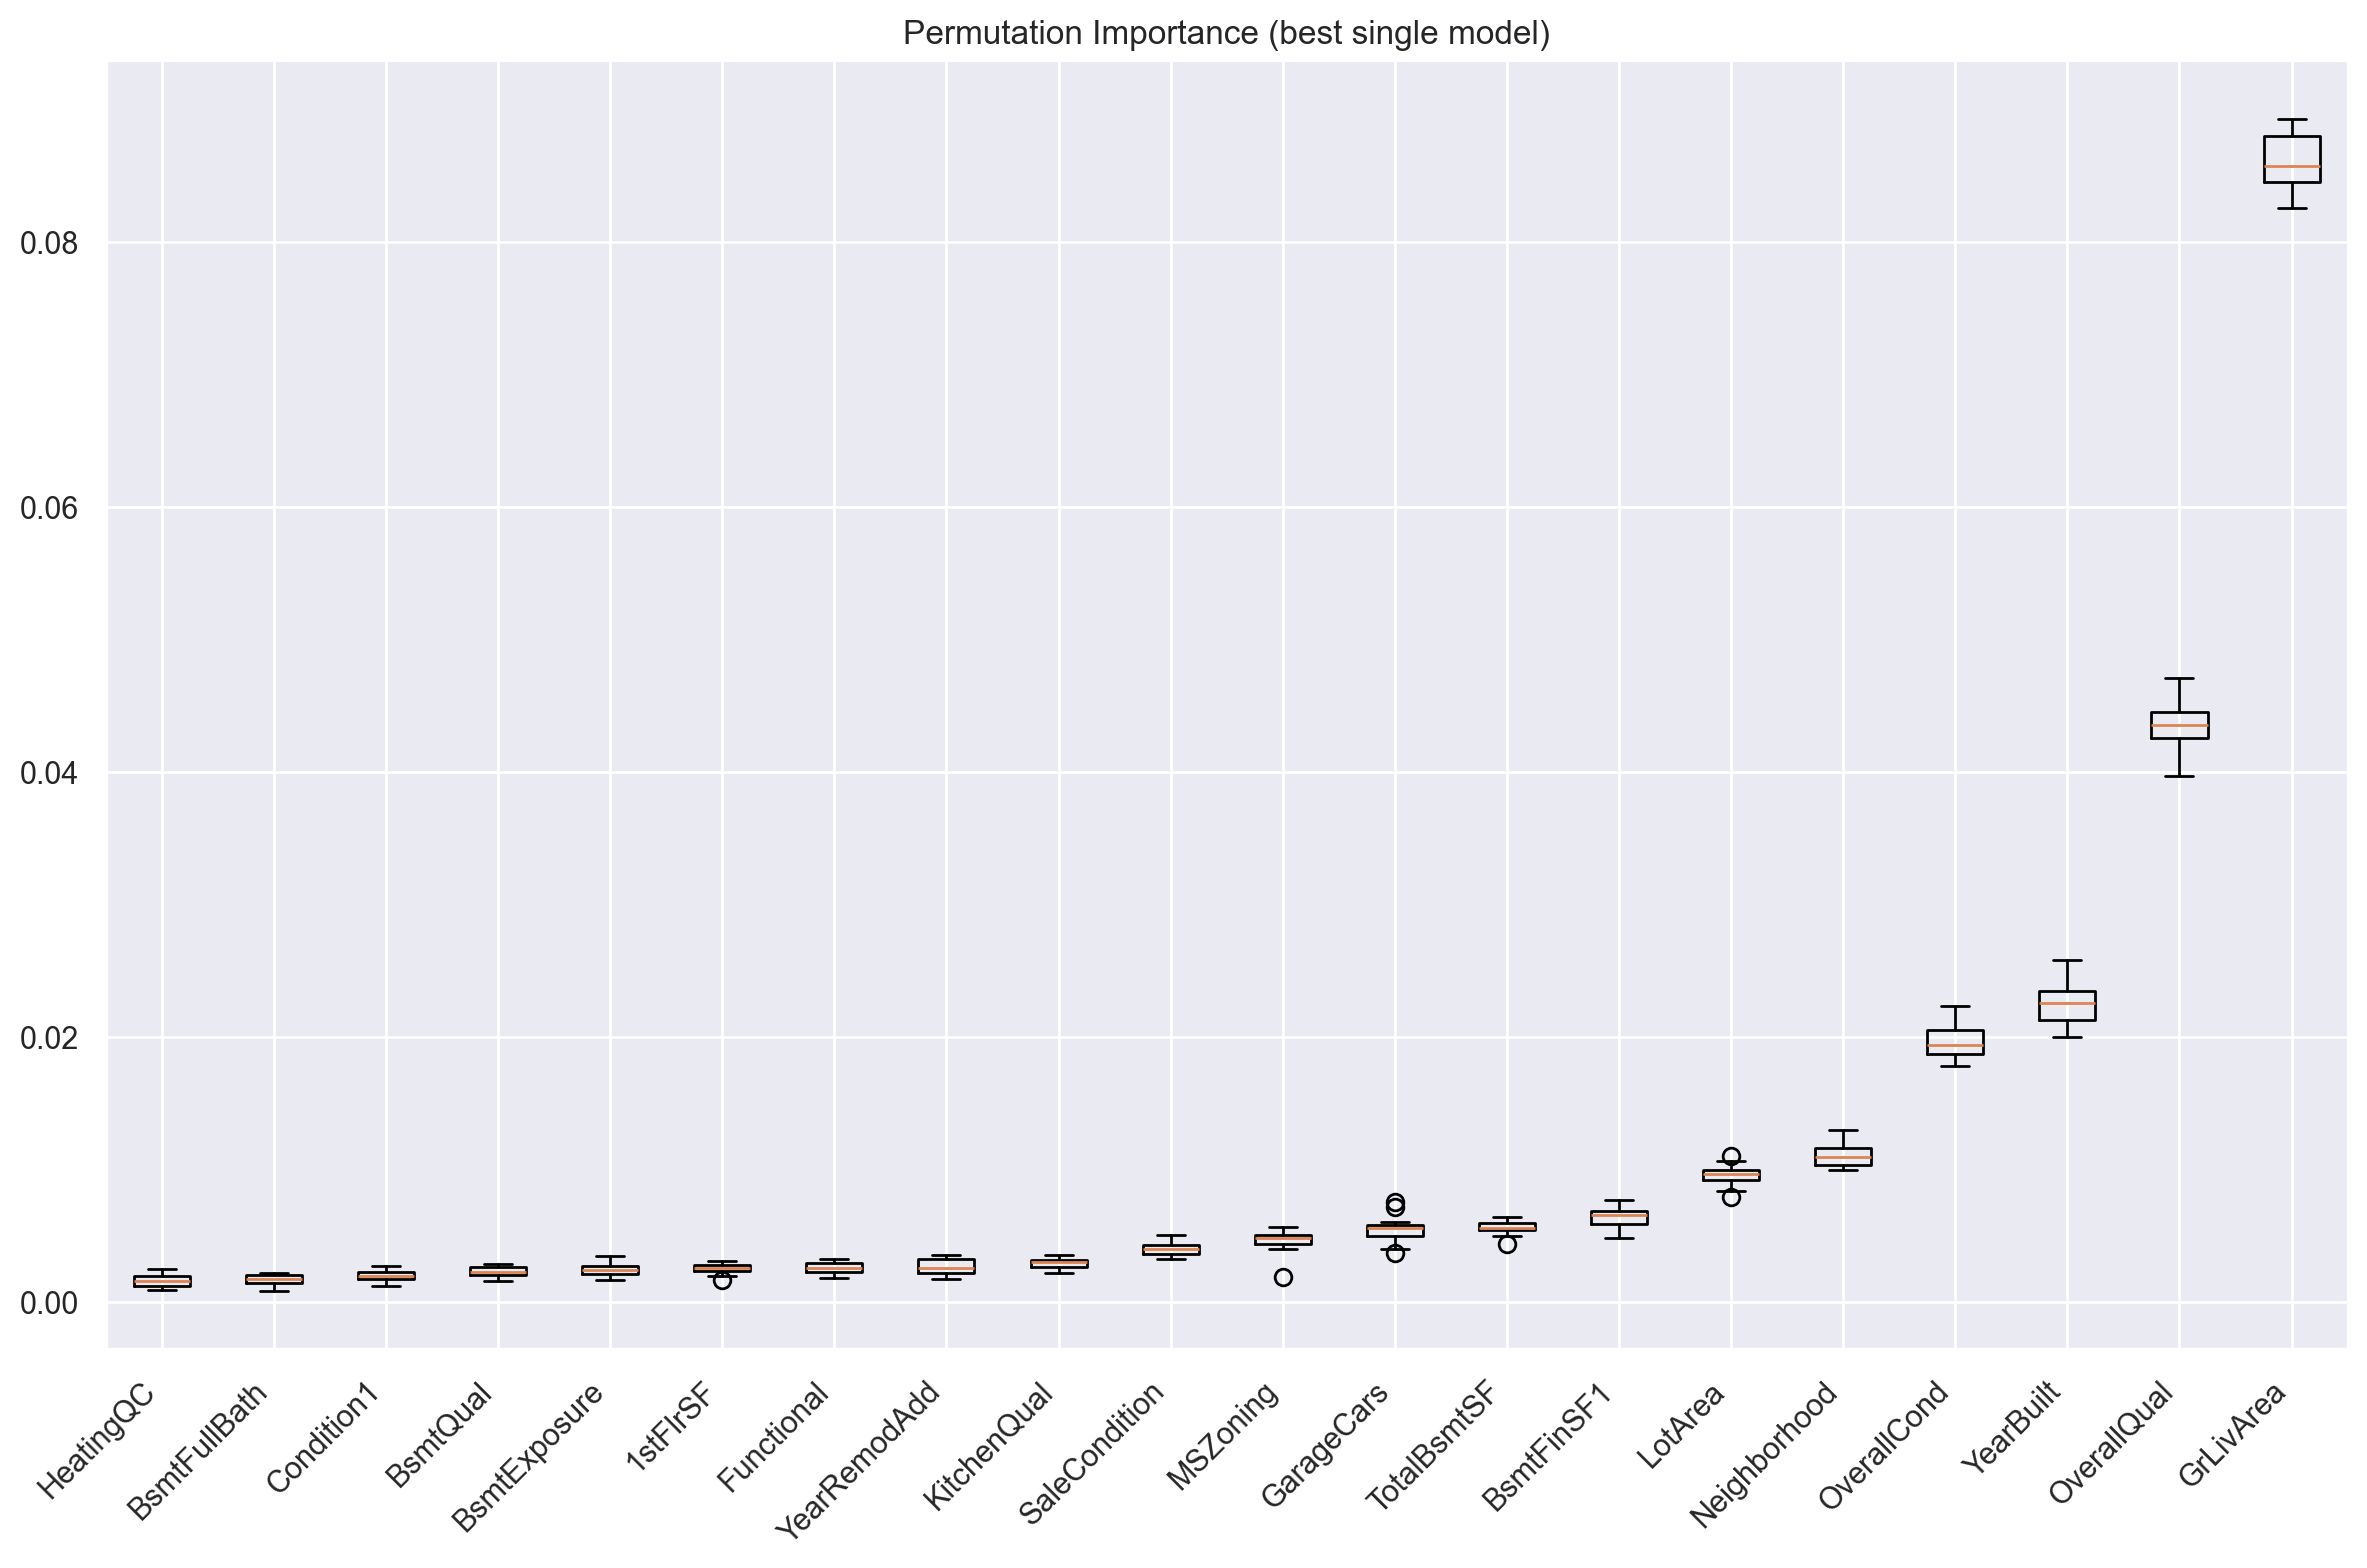

In [69]:
sorted_idx = result.importances_mean.argsort()[-20:]

fig = plt.figure(figsize=(12, 8)) 

plt.boxplot(result.importances[sorted_idx].T, 
            vert=True, 
            labels=data_X.columns[sorted_idx])

plt.title("Permutation Importance (best single model)")

plt.xticks(rotation=45, ha='right')

fig.tight_layout()
plt.show()

In [70]:
%%capture
result = permutation_importance(stacking_reg, test_X, test_y, scoring='neg_root_mean_squared_error', n_repeats=20)

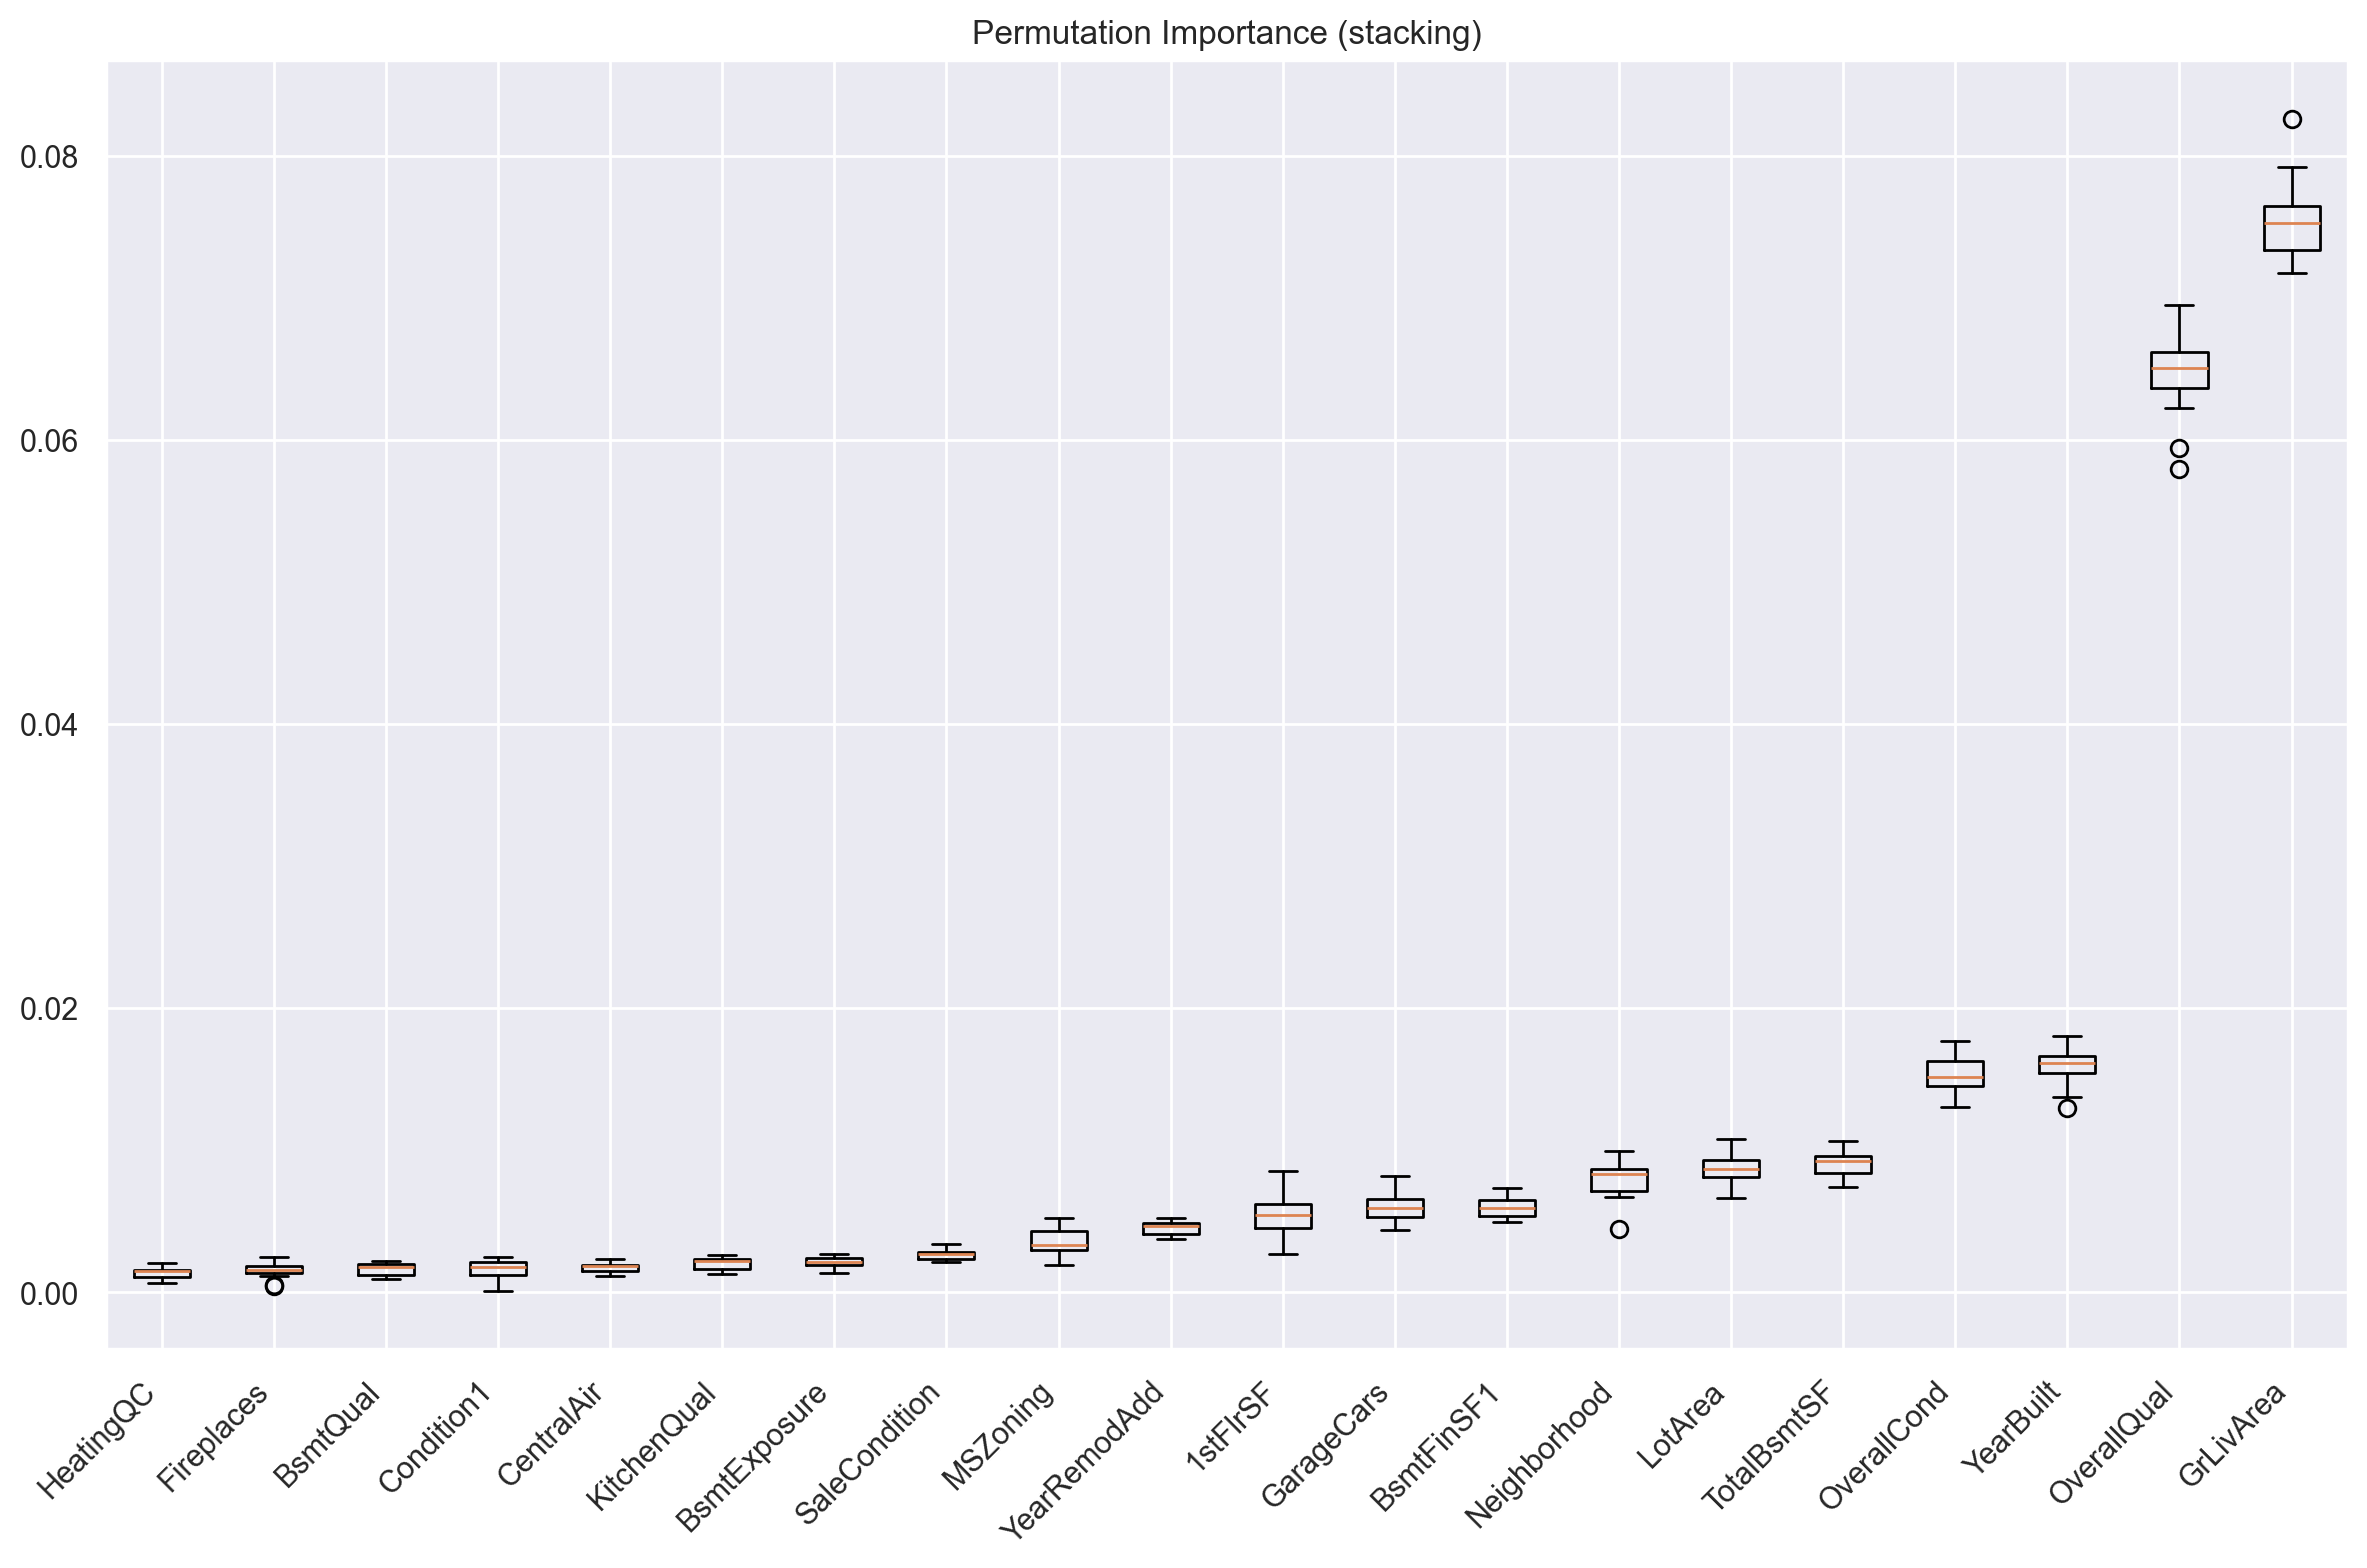

In [71]:
sorted_idx = result.importances_mean.argsort()[-20:]
fig = plt.figure(figsize=(12, 8))

plt.boxplot(result.importances[sorted_idx].T, 
            vert=True, 
            labels=data_X.columns[sorted_idx])

plt.title("Permutation Importance (stacking)")

plt.xticks(rotation=45, ha='right') 

fig.tight_layout()
plt.show()